# Probing chaos through spectral function analysis:

In this notebook I define the model 
\begin{align}
    H=J\sum_j \sigma^z_j \sigma^z_{j+1}+\lambda \sum_j \sigma^z_j \sigma^z_{j+2} + g \sum_j \sigma^x_j
\end{align}
via the Ising_Model class.

Then since TenPy doesn't have build in function to generate matrix density states (at least to the best of my knowledge), I construct the ensemble at infinite temperature by generating $N_{ensemble}$ random states and then use a random circuits function to further remove any bais on the initial states. That way observables are computed by averaging over this set of random states.

Finally to compute 
\begin{align}
    S_{ii}^{zz}(\omega)= \mathcal{FFT}\bigg(\langle e^{iHt} S_z e^{-iHt} S_z \rangle\bigg)
\end{align}
I construct the following two states using TDVP
\begin{align}
    | \psi(t) \rangle = e^{-iHt} S_z|\psi(0)\rangle
    \\
    | \phi(t) \rangle = S_z e^{-iHt}|\psi(0)\rangle
\end{align}
and compute their overlap.
  


# To Do:
- Prepare finite-temperature ensemble by using imaginary time-evolution $e^{-iHt}=e^{-\beta H} \rightarrow \beta = -it$

In [1]:
##################
# Library imports #
###################

import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed, dump

from tenpy.networks.mps import MPS
from tenpy.models.model import CouplingMPOModel
from tenpy.networks import site
from tenpy.algorithms import tdvp

Printing Hamiltonian:
1.00000 * Sigmaz_0 Sigmaz_1 +
5.00000 * Sigmaz_0 Sigmaz_2 +
1.00000 * Sigmaz_1 Sigmaz_2 +
5.00000 * Sigmaz_1 Sigmaz_3 +
1.00000 * Sigmaz_2 Sigmaz_3 +
10.00000 * Sigmax_0 +
10.00000 * Sigmax_1 +
10.00000 * Sigmax_2 +
10.00000 * Sigmax_3


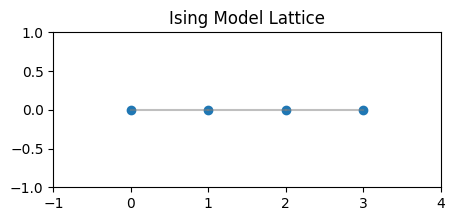

In [22]:
class Ising_Model(CouplingMPOModel):
    
    def init_sites(self, model_params):
        return site.SpinHalfSite(conserve=None)
    
    # Define model
    def init_terms(self, model_params):
        
        J = model_params.get('J', 0.5)
        g = model_params.get('g', 1.0)


        # Add coupling for all nearest neighbor pairs

        self.add_coupling(1.0, 0, 'Sigmaz', 0, 'Sigmaz', [1])

        # Add next-nearest neighbor coupling

        self.add_coupling(J, 0, 'Sigmaz', 0, 'Sigmaz', [2])

        self.add_onsite(g, 0, 'Sigmax')

def random_state(L, chi_max, sites):

    psi_random = np.random.choice(['up', 'down'], size=L).reshape(-1,1)

    MPS_random = MPS.from_lat_product_state(sites, psi_random)
#    MPS_random = MPS.from_random_unitary_evolution(sites, chi_max, psi_random, bc='finite', dtype=float)

    Sx_avg = np.mean(MPS_random.expectation_value('Sigmax'))
    Sy_avg = np.mean(MPS_random.expectation_value('Sigmay'))
    Sz_avg = np.mean(MPS_random.expectation_value('Sigmaz'))

    return MPS_random, Sx_avg, Sy_avg, Sz_avg

def spectral_function(psi0, model, times, tdvp_params):

    L = psi0.L
    S_t = np.zeros(len(times), dtype=complex)

    # Computes the first step in the time evolution of the spectral function

    #S_t[0] = psi0.overlap(psi0) # S(0) = ⟨ψ(0)|ψ(0)⟩

    # Copy do avoid overwriting original state

    ket_0 = psi0.copy()
    bra_0 = psi0.copy()

    ket_0.apply_local_op(L//2, 'Sz') # Sz|ψ(0)⟩

    ket_eng = tdvp.TwoSiteTDVPEngine(ket_0, model, tdvp_params)
    bra_eng = tdvp.TwoSiteTDVPEngine(bra_0, model, tdvp_params)

    for ti in range(1, len(times)):

        ket_eng.run()
        bra_eng.run()

        ket = ket_eng.psi # e^(-iHt) Sz|ψ(0)⟩
        bra = bra_eng.psi # e^(-iHt)|ψ(0)⟩

        psi = ket.copy()
        phi = bra.copy()

        phi.apply_local_op(L//2, 'Sz') # S_z e^(-iHt)|ψ(0)⟩

        S_t[ti] = phi.overlap(psi) # S(t) = ⟨ψ(t)|φ(t)⟩ = ⟨ψ(0)|e^(iHt) S_z e^(-iHt) S_z|ψ(0)⟩

    return S_t

# Test the model #

size = 4
J = 5.0
g = 10.0

parameters = {
    'lattice': 'Chain', 
    'L': size,
    'J': J,
    'g': g,
    'bc_MPS': 'finite',
}

test = Ising_Model(parameters)

print('Printing Hamiltonian:')
print(test.all_coupling_terms().to_TermList() + test.all_onsite_terms().to_TermList())

plt.figure(figsize=(5, 5))
ax = plt.gca()
test.lat.plot_sites(ax)
test.lat.plot_coupling(ax, test.lat.pairs['nearest_neighbors'], alpha=0.5, color='gray')
ax.set_aspect('equal')
ax.set_xlim(-1, size)
ax.set_ylim(-1, 1)
plt.title('Ising Model Lattice')
plt.show()

In [58]:
######################################################################################
# Constructs an ensemble of random states and builds respective MPS representations. #
######################################################################################

L = 10
J = 0.5
g = 10.0

model_params = {
    'lattice': 'Chain', 
    'L': L,
    'J': J,
    'g': g,
    'bc_MPS': 'finite',
}

model = Ising_Model(model_params)

sites = model.lat

N_ensemble = 30
chi_max = 4

results = Parallel(n_jobs=-1, verbose=10)(delayed(random_state)(L, chi_max, sites) for _ in range(N_ensemble))

ensemble, Sx, Sy, Sz = zip(*results)

norms = np.sqrt(np.array([psi.overlap(psi) for psi in ensemble]))

print('=' * 100)

print('Ensemble construction completed!')

print(f'Average norm across ensemble: {np.mean(norms):.4f} ± {np.std(norms):.4f}')

print(f'Average Sx across ensemble: {np.mean(Sx):.4f} ± {np.std(Sx):.4f}')
print(f'Average Sy across ensemble: {np.mean(Sy):.4f} ± {np.std(Sy):.4f}')
print(f'Average Sz across ensemble: {np.mean(Sz):.4f} ± {np.std(Sz):.4f}')

print('=' * 100)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 30 concurrent workers.


[Parallel(n_jobs=-1)]: Batch computation too fast (0.04978346824645996s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   3 out of  30 | elapsed:    0.1s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done   7 out of  30 | elapsed:    0.1s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done  11 out of  30 | elapsed:    0.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  15 out of  30 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed:    0.1s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    0.1s finished


Ensemble construction completed!
Average norm across ensemble: 1.0000 ± 0.0000
Average Sx across ensemble: 0.0000 ± 0.0000
Average Sy across ensemble: 0.0000 ± 0.0000
Average Sz across ensemble: -0.0400 ± 0.2984


In [59]:
#####################################################################################
#         Real-time evolution to compute spectral function S(t) = ⟨ψ(t)|φ(t)⟩        #
#         where φ(t) = e^(-iHt) Sz|ψ(0)⟩ and ψ(t) = Sz e^(-iHt)|ψ(0)⟩                #
#####################################################################################

dt = 0.1
t_max = 1000.0
times = np.linspace(0, t_max, int(t_max/dt))

tdvp_params = {
    'N_steps': 1,
    'dt': dt,
    'trunc_params': {
        'chi_max': 100, 
        'svd_min': 1.e-6,
    },
}

# Run spectral function calculation in parallal for all states in the ensemble

S_t = Parallel(n_jobs=-1, verbose=10)(delayed(spectral_function)(psi, model, times, tdvp_params) for psi in ensemble)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  30 | elapsed: 318.2min remaining: 2863.6min
[Parallel(n_jobs=-1)]: Done   7 out of  30 | elapsed: 320.4min remaining: 1052.7min
[Parallel(n_jobs=-1)]: Done  11 out of  30 | elapsed: 322.0min remaining: 556.3min
[Parallel(n_jobs=-1)]: Done  15 out of  30 | elapsed: 323.0min remaining: 323.0min
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed: 324.5min remaining: 187.8min
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed: 325.9min remaining: 99.2min
[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed: 327.7min remaining: 36.4min
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed: 329.6min finished


(9999,)


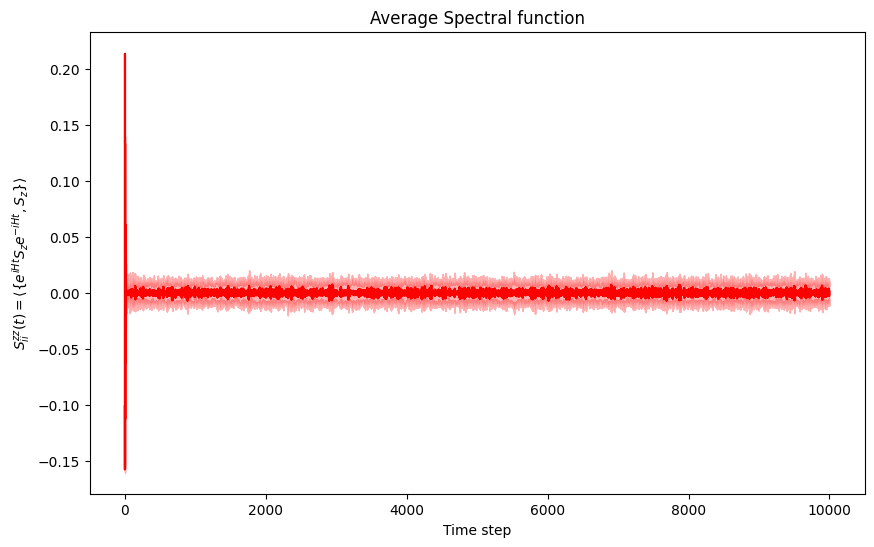

In [60]:
S_t = np.array(S_t)

S_avg = np.real(np.mean(S_t[:, 1:], axis=0))
print(S_avg.shape)
S_std = np.real(np.std(S_t[:, 1:], axis=0))

plt.figure(figsize=(10, 6))
plt.plot(S_avg, color="red")
plt.fill_between(range(len(S_avg)), S_avg - S_std, S_avg + S_std, color="red", alpha=0.3)
plt.xlabel("Time step") 
plt.ylabel(r'$S_{ii}^{zz}(t)=\langle\{ e^{iHt} S_z e^{-iHt}, S_z\}\rangle$')
plt.title("Average Spectral function")
plt.show()

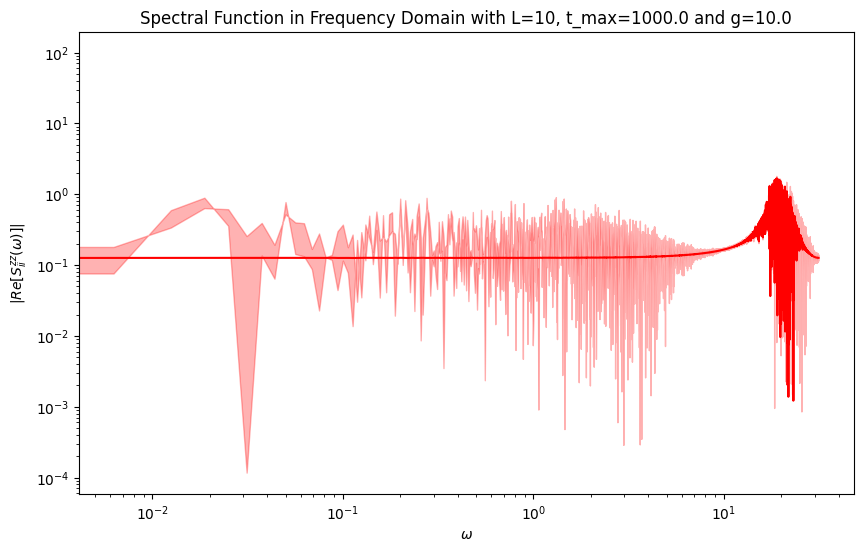

In [61]:
omega = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(int(t_max/dt)-1, d=dt))
S_fft = np.real(
    np.fft.fftshift(np.fft.fft(S_avg))
)

S_std_fft = np.real(
    np.fft.fftshift(np.fft.fft(S_std))
)

plt.figure(figsize=(10, 6))
plt.plot(omega, np.abs(S_fft), color="red")
plt.fill_between(omega, np.abs(S_fft - S_std_fft), np.abs(S_fft + S_std_fft), color="red", alpha=0.3)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$|Re[S_{ii}^{zz}(\omega)]|$')
plt.title(r'Spectral Function in Frequency Domain with L={}, t_max={:.1f} and g={}'.format(L, t_max, g))
plt.xscale('log')
plt.yscale('log')
plt.show()

